In [10]:
import radiate as rd
import polars as pl

rd.random.seed(67123)


In [11]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])


In [ ]:
target_species = 4.0
rolling = int(target_species)

anchor = rd.select("species.distance").max().rolling(rolling).mean()
count_error = (
    rd.select("count.species").rolling(rolling).mean() - target_species
) / target_species

GAIN = 0.999

result = (anchor * (count_error * GAIN + 1.0)).clamp(0.005, 2.0)
rolling_species_count = rd.select("count.species").rolling(rolling).mean()
long_rolling = rd.select("count.species").rolling(rolling * 5).mean()
spec_50_quantile = rd.select("count.species").rolling(10).quantile(0.5)


In [13]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), result)
    .metrics(
        dist_signal=result,
        species_rolling=rolling_species_count,
        long_rolling=long_rolling,
        spec_50_quantile=spec_50_quantile,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)


2026-05-12T00:02:29.746465Z  INFO Epoch 1    | Score:   2.9954 | Time: 221.29µs
2026-05-12T00:02:29.746685Z  INFO Epoch 2    | Score:   2.0038 | Time: 351.96µs
2026-05-12T00:02:29.746850Z  INFO Epoch 3    | Score:   2.0038 | Time: 464.62µs
2026-05-12T00:02:29.746971Z  INFO Epoch 4    | Score:   2.0038 | Time: 550.29µs
2026-05-12T00:02:29.747094Z  INFO Epoch 5    | Score:   2.0038 | Time: 636.67µs
2026-05-12T00:02:29.747318Z  INFO Epoch 6    | Score:   2.0038 | Time: 788.58µs
2026-05-12T00:02:29.747518Z  INFO Epoch 7    | Score:   1.7999 | Time: 932.00µs
2026-05-12T00:02:29.747710Z  INFO Epoch 8    | Score:   1.7884 | Time: 1.08ms
2026-05-12T00:02:29.747883Z  INFO Epoch 9    | Score:   1.7271 | Time: 1.20ms
2026-05-12T00:02:29.748041Z  INFO Epoch 10   | Score:   1.7271 | Time: 1.31ms
2026-05-12T00:02:29.748215Z  INFO Epoch 11   | Score:   1.7063 | Time: 1.43ms
2026-05-12T00:02:29.748361Z  INFO Epoch 12   | Score:   1.7063 | Time: 1.54ms
2026-05-12T00:02:29.748513Z  INFO Epoch 13   | Sco

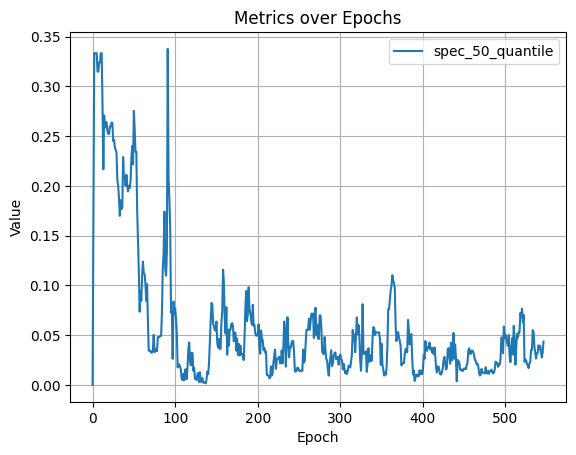

In [14]:
collector.plot(
    # "species.threshold", "count.species", "rate.diversity", "species.evenness"
    # "count.species",
    # "dist_signal",
    # "species_rolling",
    # "long_rolling",
    "spec_50_quantile",
)


In [15]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species")

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",2.0,2.0,2.0,0.0,0.0,NaN,2.0,2.0,1,null,null,null,null,null,null,0,1,"[""species"", ""statistic""]"
"""count.species""",1.0,3.0,1.5,0.707107,0.5,NaN,1.0,2.0,2,null,null,null,null,null,null,1,1,"[""species"", ""statistic""]"
"""count.species""",1.0,4.0,1.333333,0.57735,0.333333,0.0,1.0,2.0,3,null,null,null,null,null,null,2,1,"[""species"", ""statistic""]"
"""count.species""",1.0,5.0,1.25,0.5,0.25,0.0,1.0,2.0,4,null,null,null,null,null,null,3,1,"[""species"", ""statistic""]"
"""count.species""",1.0,6.0,1.2,0.447214,0.2,0.0,1.0,2.0,5,null,null,null,null,null,null,4,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",3.0,2072.0,3.815838,1.273911,1.622848,3.845231,1.0,11.0,543,null,null,null,null,null,null,542,1,"[""species"", ""statistic""]"
"""count.species""",3.0,2075.0,3.814338,1.273218,1.621083,3.867494,1.0,11.0,544,null,null,null,null,null,null,543,1,"[""species"", ""statistic""]"
"""count.species""",6.0,2081.0,3.818349,1.275488,1.626869,3.806059,1.0,11.0,545,null,null,null,null,null,null,544,1,"[""species"", ""statistic""]"


In [16]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",4.0,104.0,52.0,67.882248,4608.0,NaN,4.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.000007,0.000078,0.000039,0.000045,2.0029e-9,NaN,0.000007,0.000071,2,78µs,39µs,44µs,7µs,70µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000004,0.000004,0.000004,0.0,0.0,NaN,0.000004,0.000004,1,4µs,4µs,0µs,4µs,4µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""species_rolling""",4.75,2086.083252,3.813681,0.806265,0.650063,0.0,1.0,6.25,547,null,null,null,null,null,null,546,1,"[""species"", ""statistic"", ""expr""]"
"""long_rolling""",3.4,2081.201172,3.804755,0.388068,0.150596,0.0,1.2,4.6,547,null,null,null,null,null,null,546,1,"[""statistic"", ""expr""]"
"""spec_50_quantile""",0.043512,32.782913,0.059932,0.069877,0.004883,0.0,0.0,0.337629,547,null,null,null,null,null,null,546,1,"[""statistic"", ""expr""]"


In [17]:
print(result.index())
last_version = df.select("version").max().item()
last_version

547


ColumnNotFoundError: unable to find column "version"; valid columns: ["name", "last", "sum", "mean", "stddev", "var", "skew", "min", "max", "count", "time_sum", "time_mean", "time_stddev", "time_min", "time_max", "time_var", "generation", "update_count", "tags"]